# BEATs (Job)
Ik heb de unilm/beats repo gebruikt voor de beats, dit is alsnog diegene van de challenge. Voor de imports gebruik ik deze. Je moet deze zelf clonen https://github.com/microsoft/unilm/tree/master/beats. Ook heel belangrijk is dat je de BEATs_iter3_plus_AS2M.pt file hebt gedownload (kan via de readme van de bovenstaande github repo)

In [1]:
import os
import sys
import torch
import torchaudio
import numpy as np
sys.path.append(r"C:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\unilm\beats")
from BEATs import BEATs, BEATsConfig
import torch.nn as nn

In [2]:
from config import iter_all_data, get_features_path

# Process all available machines across all years
for year, machine, input_folder in iter_all_data():
    output_folder = get_features_path(year, machine, dataset="dev")
    print(f"\nProcessing {year} - {machine}")
    print(f"  Input:  {input_folder}")
    print(f"  Output: {output_folder}")
    
    # Your extraction code here
    
    # process_machine_data(input_folder, output_folder)


Processing dcase2023t2 - ToyCar
  Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyCar
  Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\dcase2023t2_features\dev_features\raw_features\ToyCar_features

Processing dcase2023t2 - ToyTrain
  Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\ToyTrain
  Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\dcase2023t2_features\dev_features\raw_features\ToyTrain_features

Processing dcase2023t2 - bearing
  Input:  c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data\dcase2023t2\dev_data\raw\bearing
  Output: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\features\dcase2023t2

In [ ]:
# import glob

# # 1. Get the directory of the current notebook
# notebook_dir = os.getcwd()

# # 2. Try to find the 'data' folder by looking at current and parent dirs
# if os.path.exists(os.path.join(notebook_dir, "data")):
#     data_path = os.path.join(notebook_dir, "data")
# elif os.path.exists(os.path.join(notebook_dir, "..", "data")):
#     data_path = os.path.join(notebook_dir, "..", "data")
# else:
#     print("❌ Could not find 'data' folder. Please check your folder structure.")
#     data_path = None

# if data_path:
#     # Get all .wav files
#     audio_files = glob.glob(os.path.join(data_path, "**", "*.wav"), recursive=True)
#     print(f"✅ Found {len(audio_files)} files in: {os.path.abspath(data_path)}")

✅ Found 54300 files in: c:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\data


## Load model
Hier wordt het model geladen (vanuit de git repository die net gecloned is) en vervolgens wordt de 'checkpoint' geladen. Dit zijn de getrainde weights. Ook is het handig als je CUDA hebt, dan gebruikt je laptop je GPU ipv je CPU. Dit is net wat sneller maar wel wat werk om aan de praat te krijgen. 

In [4]:
checkpoint_path = "BEATs_iter3_plus_AS2M.pt" 
checkpoint = torch.load(checkpoint_path, map_location="cpu")
cfg = BEATsConfig(checkpoint["cfg"])  # Wrap dict in config object

# Initialize BEATs
model = BEATs(cfg)
model.load_state_dict(checkpoint["model"])
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

C:\Users\20202299\AppData\Local\Temp\ipykernel_17900\242675626.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu

BEATs(
  (post_extract_proj): Linear(in_features=512, out_features=768, bias=True)
  (patch_embedding): Conv2d(1, 512, kernel_size=(16, 16), stride=(16, 16), bias=False)
  (dropout_input): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (pos_conv): Sequential(
      (0): Conv1d(768, 768, kernel_size=(128,), stride=(1,), padding=(64,), groups=16)
      (1): SamePad()
      (2): GELU(approximate='none')
    )
    (layers): ModuleList(
      (0): TransformerSentenceEncoderLayer(
        (self_attn): MultiheadAttention(
          (dropout_module): Dropout(p=0.1, inplace=False)
          (relative_attention_bias): Embedding(320, 12)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (grep_linear): Linear(in_features=64, out

## Prepocess data
Hier zou data augmentatie aan toegevoegd kunnen worden

In [5]:
def load_audio(file_path, target_sr=16000):
    waveform, sr = torchaudio.load(file_path)
    # Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)  # Make sure it's 1D
    # Resample
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform.unsqueeze(0), sr, target_sr).squeeze(0)
    # Pad short waveforms to 400 samples (25ms)
    if waveform.shape[0] < 400:
        pad_len = 400 - waveform.shape[0]
        waveform = torch.nn.functional.pad(waveform, (0, pad_len))
    return waveform

def extract_beats_embedding(waveform):
    waveform = waveform.to(device)
    with torch.no_grad():
        features, _ = model.extract_features(waveform.unsqueeze(0))  # [1, T, 768]
        clip_embedding = features.mean(dim=1).squeeze(0).cpu().numpy()  # [768]
    return clip_embedding

## Embeddings uit 1 machine halen (duurt ong 10-13 min)
Nu heeft de BEATs model 768 features voor iedere clip gehaald. Deze features kun je in een ander model stoppen om hem uiteindelijk te classifien. 

In [6]:
# from config import iter_all_data, get_features_path

# # Process all machines across all years
# for year, machine, input_folder in iter_all_data():
#     output_folder = get_features_path(year, machine, dataset="dev")
#     print(f"\n🔄 Processing {year} - {machine}")
#     print(f"  📁 Input:  {input_folder}")
#     print(f"  💾 Output: {output_folder}")

#     # skip if extraction already done (>=1000 files)
#     existing = list(output_folder.rglob("*.npy"))
#     if len(existing) >= 1000:
#         print(f"  ⏭️ Skipping {machine} - {len(existing)} features already present")
#         continue

#     # Process all .wav files in this machine's train folder
#     train_input = input_folder / "train"
#     if not train_input.exists():
#         print(f"  ⚠️  Skipping {machine} - no train folder found")
#         continue

#     # Count files first
#     wav_files = list(train_input.glob("**/*.wav"))
#     if not wav_files:
#         print(f"  ⚠️  Skipping {machine} - no .wav files found")
#         continue

#     print(f"  🎵 Found {len(wav_files)} audio files")

#     # Process each file
#     processed_count = 0
#     for wav_file in wav_files:
#         try:
#             # Load and process audio
#             waveform = load_audio(str(wav_file))
#             embedding = extract_beats_embedding(waveform)

#             # Create output path (mirror input structure)
#             relative_path = wav_file.relative_to(train_input)
#             out_file = output_folder / relative_path.with_suffix('.npy')
#             out_file.parent.mkdir(parents=True, exist_ok=True)

#             # Save embedding
#             np.save(out_file, embedding)
#             processed_count += 1

#         except Exception as e:
#             print(f"  ❌ Error processing {wav_file}: {e}")

#     print(f"  ✅ Processed {processed_count}/{len(wav_files)} files")

# print("\n🎉 All feature extraction completed!")

## PCA

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from config import iter_all_data, get_features_path
import pickle
import os

# Function to apply PCA to a single machine's features
def apply_pca_to_machine(year, machine, features_path):
    """Apply PCA to features of a specific machine and save results"""

    # Find all .npy files for this machine (excluding pca subdirectory which may contain reduced features)
    embedding_files = [f for f in features_path.glob("**/*.npy") if "pca" not in str(f)]
    if not embedding_files:
        print(f"⚠️  No feature files found for {year}-{machine}")
        return None, None

    print(f"📊 Processing {len(embedding_files)} features for {year}-{machine}")

    # Load all embeddings
    embeddings_list = []
    for file in embedding_files:
        try:
            emb = np.load(file)
            embeddings_list.append(emb)
        except Exception as e:
            print(f"❌ Error loading {file}: {e}")

    if not embeddings_list:
        print(f"⚠️  No valid embeddings for {year}-{machine}")
        return None, None

    X_np = np.vstack(embeddings_list)
    print(f"   Original shape: {X_np.shape}")

    # 1. Full PCA for variance analysis
    pca_full = PCA()
    pca_full.fit(X_np)

    # 2. Plot explained variance (optional - only for first few machines to avoid clutter)
    # if year == "dcase2023t2" and machine == "bearing":  # Show plot for first machine only
    #     plt.figure(figsize=(8, 5))
    #     plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
    #     plt.xlabel('Number of Components')
    #     plt.ylabel('Cumulative Explained Variance')
    #     plt.title(f'PCA Explained Variance: {year}-{machine}')
    #     plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
    #     plt.legend()
    #     plt.grid()
    #     plt.show()

    # 3. Apply PCA with 95% variance threshold
    pca_reduced = PCA(n_components=0.95)
    X_pca = pca_reduced.fit_transform(X_np)

    print(f"   Reduced shape: {X_pca.shape} (components: {pca_reduced.n_components_})")

    # 4. Save PCA results
    pca_dir = features_path / "pca"
    pca_dir.mkdir(exist_ok=True)

    # Save reduced features
    np.save(pca_dir / "features_pca.npy", X_pca)

    # Save PCA model for future use
    with open(pca_dir / "pca_model.pkl", 'wb') as f:
        pickle.dump(pca_reduced, f)

    # Save explained variance info
    variance_info = {
        'explained_variance_ratio': pca_reduced.explained_variance_ratio_,
        'cumulative_variance': np.cumsum(pca_reduced.explained_variance_ratio_),
        'n_components': pca_reduced.n_components_,
        'original_shape': X_np.shape,
        'reduced_shape': X_pca.shape
    }
    np.save(pca_dir / "variance_info.npy", variance_info)

    return X_pca, pca_reduced

# Process all machines
print("🚀 Starting PCA processing for all machines...\n")

pca_results = {}
for year, machine, _ in iter_all_data():
    features_path = get_features_path(year, machine, dataset="dev")

    if not features_path.exists():
        print(f"⚠️  Features directory not found: {features_path}")
        continue

    print(f"\n🔄 Processing {year} - {machine}")
    X_pca, pca_model = apply_pca_to_machine(year, machine, features_path)

    if X_pca is not None:
        pca_results[f"{year}_{machine}"] = {
            'features': X_pca,
            'model': pca_model,
            'path': features_path
        }

print(f"\n✅ PCA completed for {len(pca_results)} machines!")
print("📁 PCA results saved in each machine's features/pca/ directory")

🚀 Starting PCA processing for all machines...


🔄 Processing dcase2023t2 - ToyCar
📊 Processing 1000 features for dcase2023t2-ToyCar
   Original shape: (1000, 768)
   Reduced shape: (1000, 81) (components: 81)

🔄 Processing dcase2023t2 - ToyTrain
📊 Processing 1000 features for dcase2023t2-ToyTrain
   Original shape: (1000, 768)
   Reduced shape: (1000, 108) (components: 108)

🔄 Processing dcase2023t2 - bearing
📊 Processing 1000 features for dcase2023t2-bearing
   Original shape: (1000, 768)
   Reduced shape: (1000, 99) (components: 99)

🔄 Processing dcase2023t2 - fan
📊 Processing 1000 features for dcase2023t2-fan
   Original shape: (1000, 768)
   Reduced shape: (1000, 22) (components: 22)

🔄 Processing dcase2023t2 - gearbox
📊 Processing 1000 features for dcase2023t2-gearbox
   Original shape: (1000, 768)
   Reduced shape: (1000, 89) (components: 89)

🔄 Processing dcase2023t2 - valve
📊 Processing 1000 features for dcase2023t2-valve
   Original shape: (1000, 768)
   Reduced shape: (1000, 

📊 Loaded PCA results for dcase2025t2-bearing
   Shape: (1000, 124)
   Components: 124
.2f


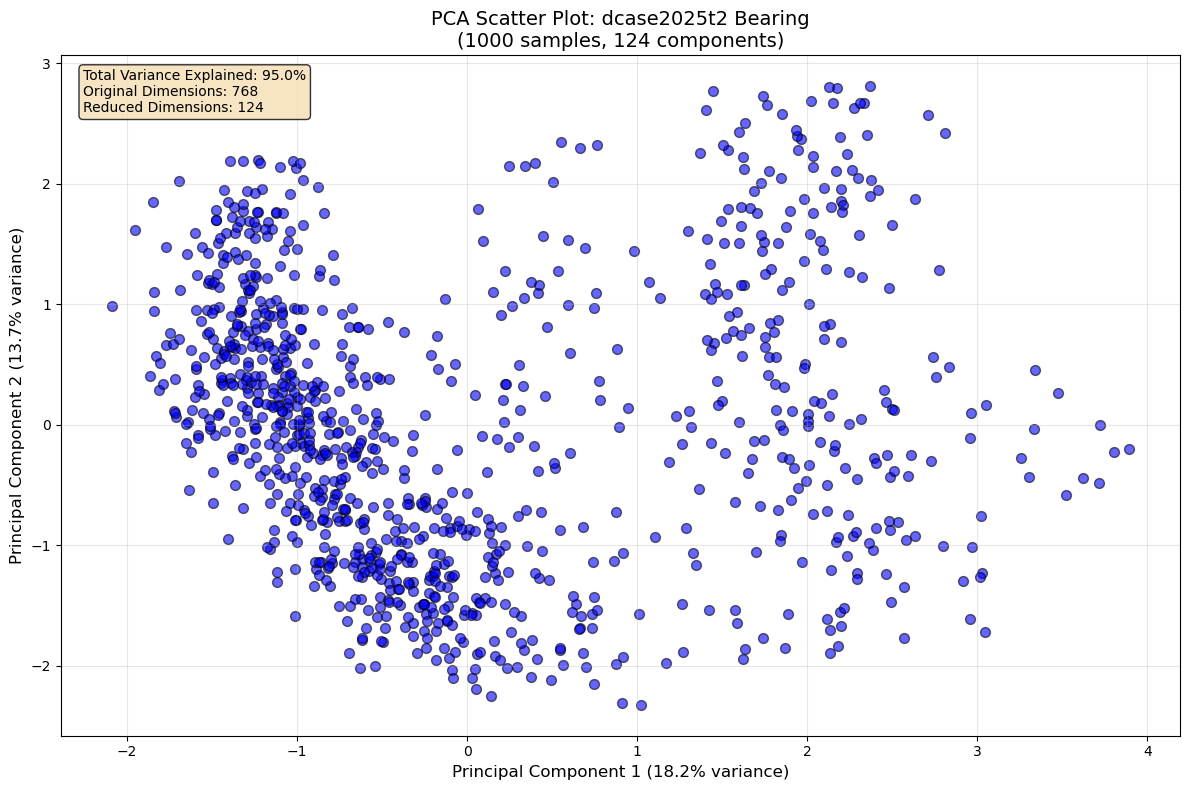

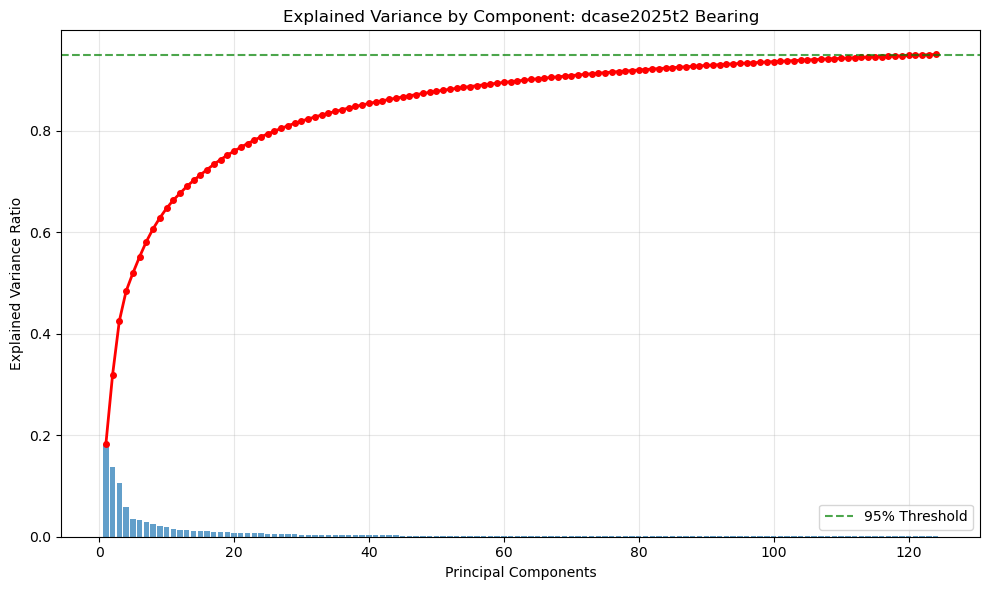

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from config import get_features_path

# Load PCA results for visualization
def load_pca_results(year, machine, dataset="dev"):
    """Load PCA results for a specific machine"""
    features_path = get_features_path(year, machine, dataset)
    pca_dir = features_path / "pca"
    
    if not pca_dir.exists():
        print(f"⚠️  PCA results not found for {year}-{machine}")
        return None, None
    
    # Load PCA features
    features_file = pca_dir / "features_pca.npy"
    variance_file = pca_dir / "variance_info.npy"
    
    if not features_file.exists() or not variance_file.exists():
        print(f"⚠️  PCA files missing for {year}-{machine}")
        return None, None
    
    X_pca = np.load(features_file)
    variance_info = np.load(variance_file, allow_pickle=True).item()
    
    return X_pca, variance_info

# Create scatter plot for bearing machine (2025)
year, machine = "dcase2025t2", "bearing"
X_pca, variance_info = load_pca_results(year, machine)

if X_pca is not None:
    print(f"📊 Loaded PCA results for {year}-{machine}")
    print(f"   Shape: {X_pca.shape}")
    print(f"   Components: {variance_info['n_components']}")
    print(".2f")
    
    # Create scatter plot
    plt.figure(figsize=(12, 8))
    
    # Plot first 2 components
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                         alpha=0.6, c='blue', edgecolors='k', s=50)
    
    plt.xlabel(f'Principal Component 1 ({variance_info["explained_variance_ratio"][0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({variance_info["explained_variance_ratio"][1]:.1%} variance)', fontsize=12)
    plt.title(f'PCA Scatter Plot: {year} {machine.title()}\n({X_pca.shape[0]} samples, {variance_info["n_components"]} components)', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add variance information as text
    variance_text = f"""Total Variance Explained: {variance_info['cumulative_variance'][-1]:.1%}
Original Dimensions: {variance_info['original_shape'][1]}
Reduced Dimensions: {variance_info['reduced_shape'][1]}"""
    
    plt.text(0.02, 0.98, variance_text, transform=plt.gca().transAxes, 
             verticalalignment='top', fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Optional: Plot explained variance
    plt.figure(figsize=(10, 6))
    components = range(1, len(variance_info['explained_variance_ratio']) + 1)
    plt.bar(components, variance_info['explained_variance_ratio'], alpha=0.7)
    plt.plot(components, variance_info['cumulative_variance'], 'r-o', linewidth=2, markersize=4)
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.title(f'Explained Variance by Component: {year} {machine.title()}')
    plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95% Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"❌ Could not load PCA results for {year}-{machine}")

⚠️  PCA results not found for dcase2024t2-ToyTrain
⚠️  PCA results not found for dcase2024t2-bearing
⚠️  PCA results not found for dcase2024t2-fan
⚠️  PCA results not found for dcase2024t2-gearbox
⚠️  PCA results not found for dcase2024t2-slider
⚠️  PCA results not found for dcase2024t2-valve
⚠️  PCA results not found for dcase2025t2-ToyCar
⚠️  PCA results not found for dcase2025t2-ToyTrain
⚠️  PCA results not found for dcase2025t2-fan
⚠️  PCA results not found for dcase2025t2-gearbox
⚠️  PCA results not found for dcase2025t2-slider
⚠️  PCA results not found for dcase2025t2-valve


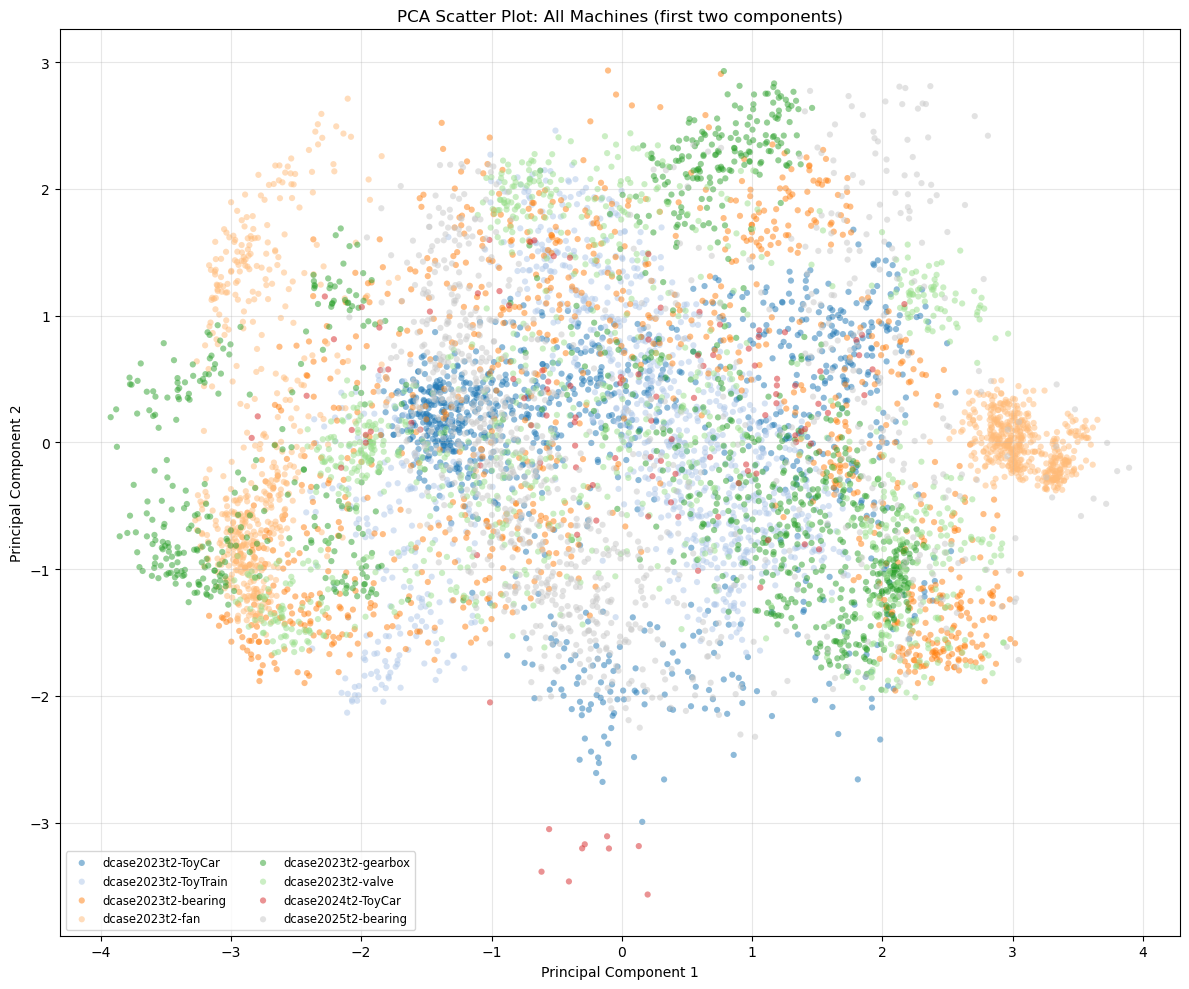

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from config import iter_all_data

# Create a combined scatterplot across machines
plt.figure(figsize=(12, 10))
colors = plt.cm.tab20.colors

for idx, (year, machine, _) in enumerate(iter_all_data()):
    X_pca, variance_info = load_pca_results(year, machine)
    if X_pca is None:
        continue
    color = colors[idx % len(colors)]
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5,
                s=20, label=f"{year}-{machine}", color=color, edgecolors='none')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter Plot: All Machines (first two components)')
plt.legend(loc='best', fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

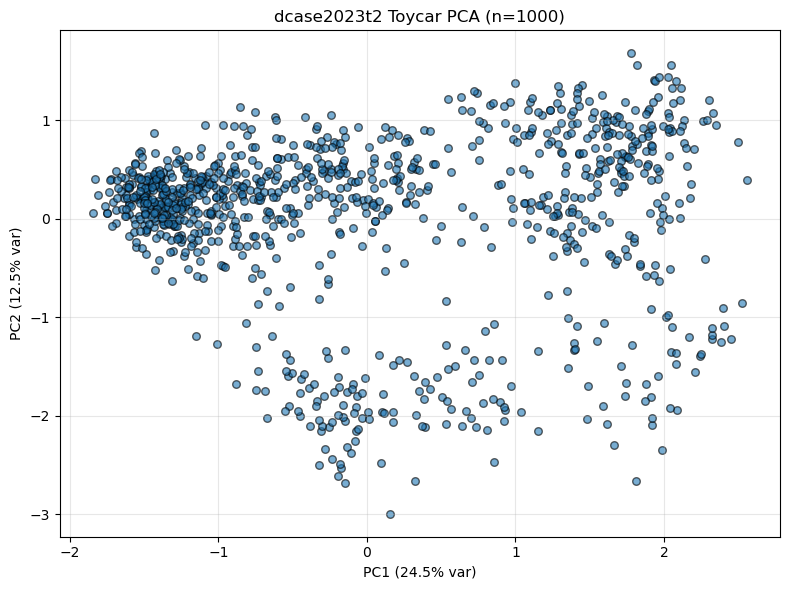

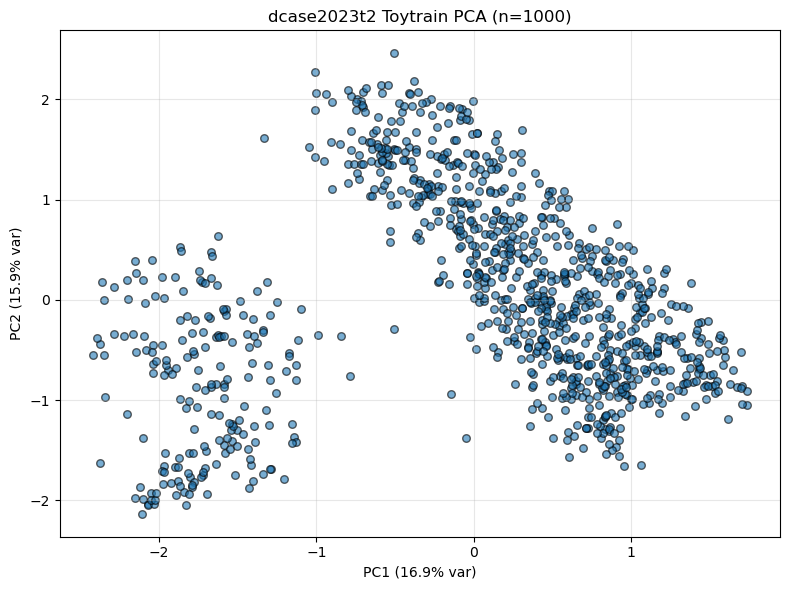

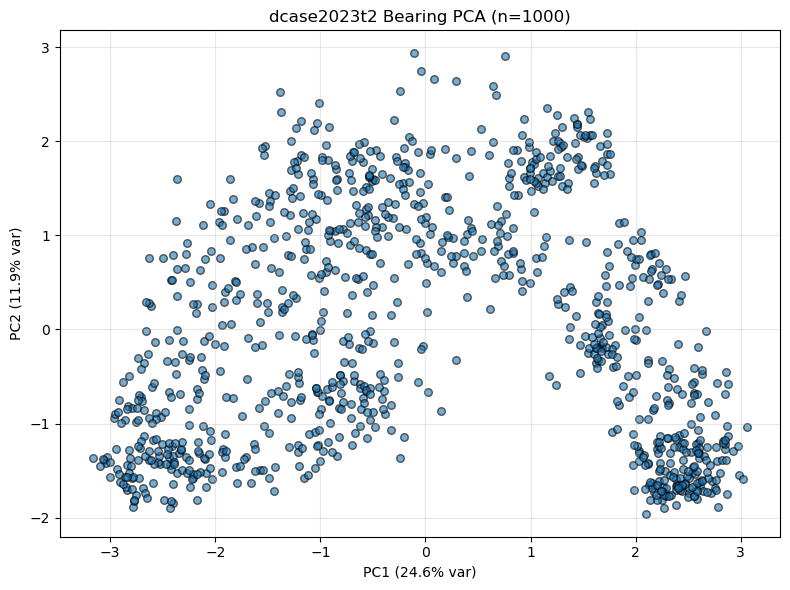

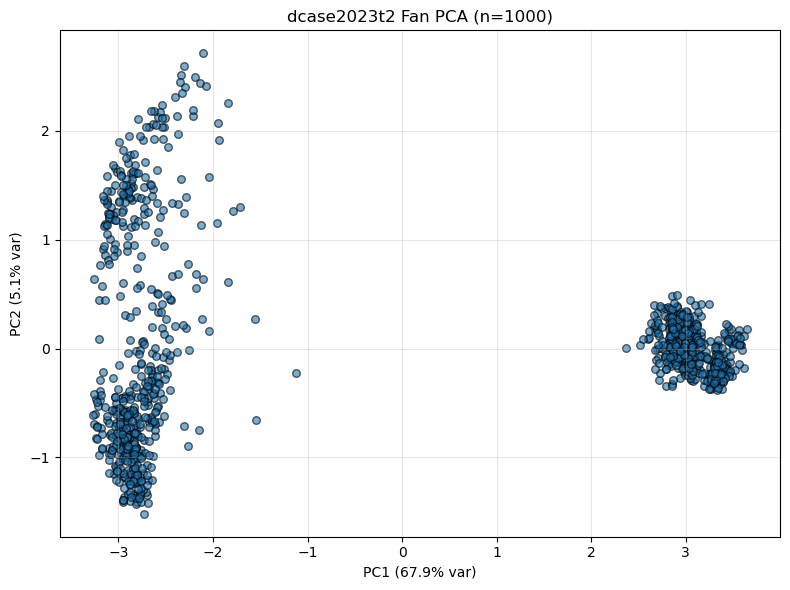

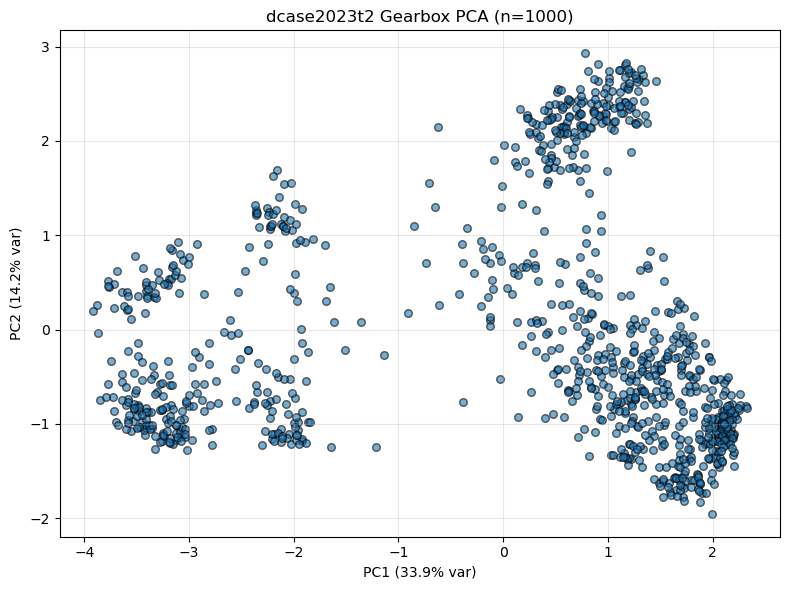

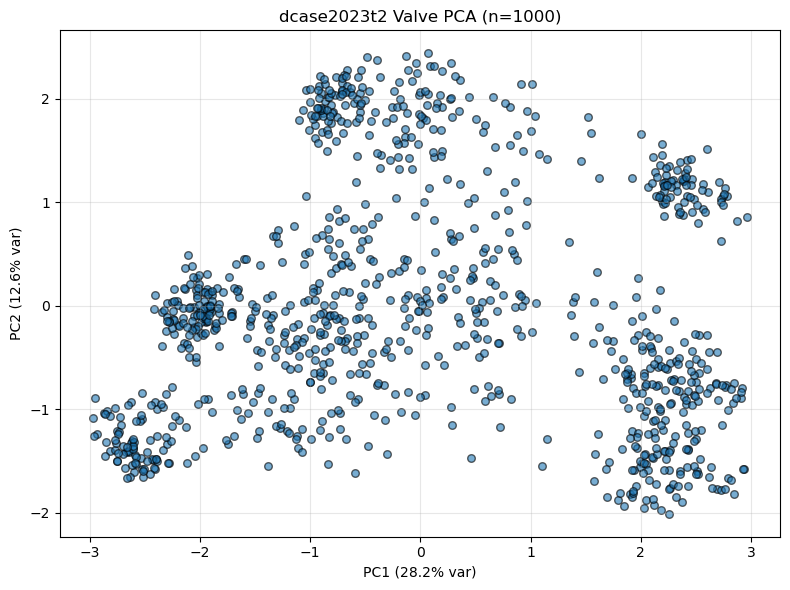

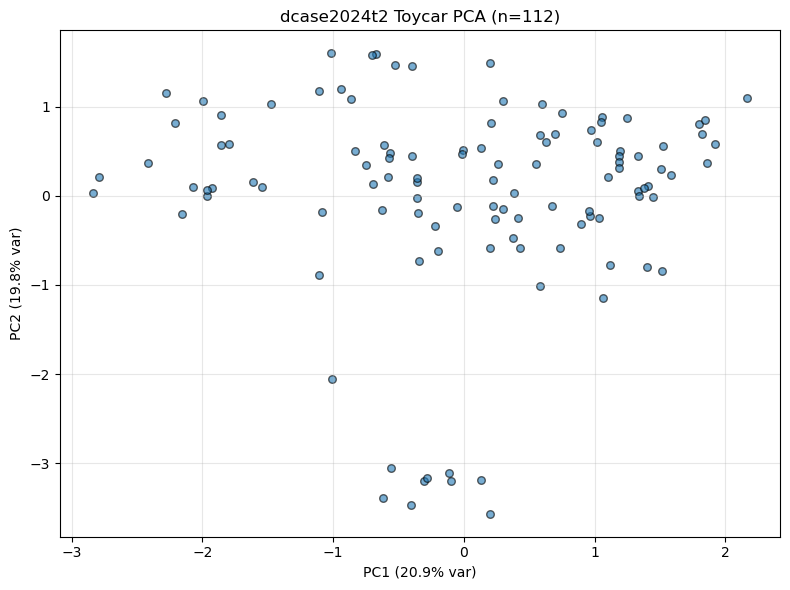

⚠️  PCA results not found for dcase2024t2-ToyTrain
⚠️  PCA results not found for dcase2024t2-bearing
⚠️  PCA results not found for dcase2024t2-fan
⚠️  PCA results not found for dcase2024t2-gearbox
⚠️  PCA results not found for dcase2024t2-slider
⚠️  PCA results not found for dcase2024t2-valve
⚠️  PCA results not found for dcase2025t2-ToyCar
⚠️  PCA results not found for dcase2025t2-ToyTrain


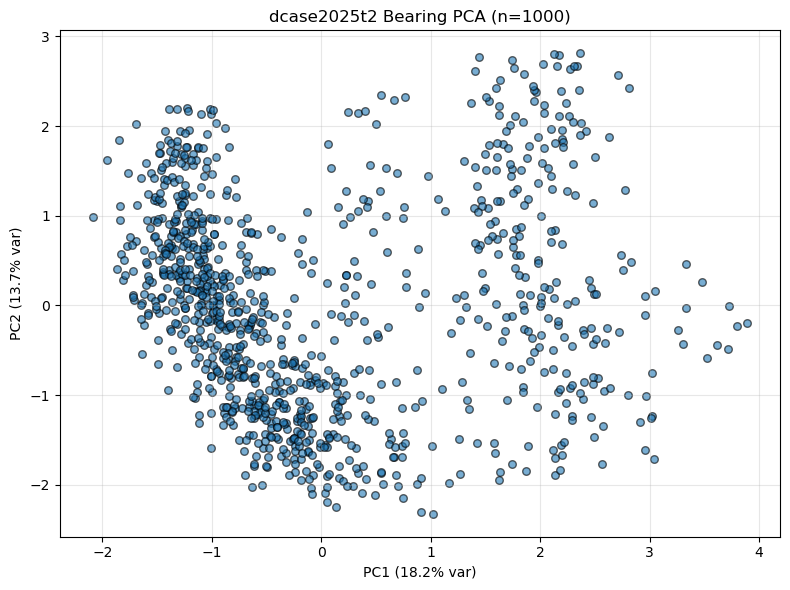

⚠️  PCA results not found for dcase2025t2-fan
⚠️  PCA results not found for dcase2025t2-gearbox
⚠️  PCA results not found for dcase2025t2-slider
⚠️  PCA results not found for dcase2025t2-valve


In [15]:
# Generate individual PCA scatterplots for each machine
import matplotlib.pyplot as plt

for year, machine, _ in iter_all_data():
    X_pca, variance_info = load_pca_results(year, machine)
    if X_pca is None:
        continue
    
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6, s=30, edgecolors='k')
    plt.xlabel(f'PC1 ({variance_info["explained_variance_ratio"][0]:.1%} var)')
    plt.ylabel(f'PC2 ({variance_info["explained_variance_ratio"][1]:.1%} var)')
    plt.title(f'{year} {machine.title()} PCA (n={X_pca.shape[0]})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Example classifier head

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Create labels (all samples are from normal training data)
labels = np.zeros(X_pca.shape[0], dtype=int)  # 0 = normal

# Split the PCA-reduced data
X_train, X_test, y_train, y_test = train_test_split(X_pca, labels, test_size=0.2, random_state=42)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluate
accuracy = knn.score(X_test, y_test)
print(f"KNN Classification Accuracy: {accuracy:.4f}")

# Optional: Predict on a few test samples
predictions = knn.predict(X_test[:10])
print("Predictions for first 10 test samples:", predictions)
print("Actual labels:", y_test[:10])

KNN Classification Accuracy: 1.0000
Predictions for first 10 test samples: [0 0 0 0 0 0 0 0 0 0]
Actual labels: [0 0 0 0 0 0 0 0 0 0]


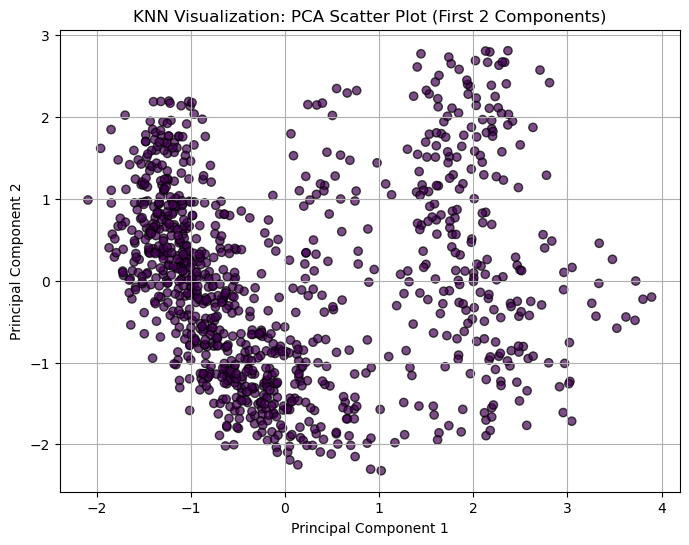

In [ ]:
import matplotlib.pyplot as plt

# Visualize the PCA-reduced data in 2D (first two components)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KNN Visualization: PCA Scatter Plot (First 2 Components)')
plt.grid(True)
plt.show()

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ====== 1️⃣ Paths ======bearing\
features_folder = r"C:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\bearing_features"
output_csv = r"C:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\anomaly_scores.csv"

# ====== 2️⃣ Load all embeddings ======
all_files = []
for root, _, files in os.walk(features_folder):
    for file in files:
        if file.endswith(".npy"):
            all_files.append(os.path.join(root, file))

embeddings_list = []
file_paths = []
for f in all_files:
    emb = np.load(f)
    embeddings_list.append(emb)
    file_paths.append(f)

X = np.stack(embeddings_list)  # [N, 768]
X = torch.tensor(X, dtype=torch.float32)
print("Loaded embeddings shape:", X.shape)

# ====== 3️⃣ Define Autoencoder ======
class AE(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# ====== 4️⃣ Prepare DataLoader ======
batch_size = 32
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ====== 5️⃣ Initialize model ======
device = "cuda" if torch.cuda.is_available() else "cpu"
ae = AE().to(device)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# ====== 6️⃣ Train Autoencoder ======
epochs = 50
for epoch in range(epochs):
    epoch_loss = 0
    for batch in loader:
        x_batch = batch[0].to(device)
        optimizer.zero_grad()
        x_hat = ae(x_batch)
        loss = loss_fn(x_hat, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)
    epoch_loss /= len(loader.dataset)
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.6f}")

# ====== 7️⃣ Compute anomaly scores ======
ae.eval()
scores = []
with torch.no_grad():
    for emb, path in zip(X, file_paths):
        emb = emb.to(device)
        recon = ae(emb)
        score = torch.norm(emb - recon).item()  # L2 reconstruction error
        scores.append((path, score))

# ====== 8️⃣ Save anomaly scores ======
import csv
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file", "anomaly_score"])
    writer.writerows(scores)

print(f"✅ Anomaly scores saved to {output_csv}")

Loaded embeddings shape: torch.Size([1000, 768])
Epoch 1/50 Loss: 0.044885
Epoch 11/50 Loss: 0.006224
Epoch 21/50 Loss: 0.004918
Epoch 31/50 Loss: 0.004328
Epoch 41/50 Loss: 0.003941
Epoch 50/50 Loss: 0.003683
✅ Anomaly scores saved to C:\Users\20202299\OneDrive - TU Eindhoven\Master AIES\Team_Internship\Team-Internship-Sorama\anomaly_scores.csv
